# H2 — H1 후보군 분포 검정

**H2 가설:** H1에서 도출한 성장 정체 후보군의 비율은 캐릭터 속성인 레벨 구간 및 직업 계열에 따라 불균일하게 분포할 것이다.

H1 K-Means 클러스터 후보 `is_stagnant_cluster`(6mo·4피처·k=4, **380명**)를 **단일 라벨**로 두고,
레벨 구간과 직업 계열에 걸친 분포를 카이제곱 독립성 검정으로 분석한다. 과거 현재성 보조 라벨(현재성·고신뢰)은
폐기되어(`temporal_external_validation` 삭제) 사용하지 않는다. 모든 수치는 결과물 산출을 `run_analysis.py`로
재현·재호출하고, 변경 전 데이터와 충돌나지 않게 단일 라벨 기준으로 통일한다.


In [1]:
from pathlib import Path
import json
import subprocess
import sys

import pandas as pd
from IPython.display import Image, Markdown, display

root = Path.cwd()
h2_dir = root / "h2_distribution" if (root / "h2_distribution").exists() else root
subprocess.run([sys.executable, str(h2_dir / "run_analysis.py")], check=True)
results = json.loads((h2_dir / "results.json").read_text(encoding="utf-8"))

C:\Users\Ladinz\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\Ladinz\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


## 기본 검정

단일 H2 가설을 `is_stagnant_cluster`(380)의 레벨 구간·직업 계열 두 교차표로 검정한다.
`p`는 카이제곱 근사값이며 Monte Carlo p는 주변합을 고정한 보수적 점검, Holm 보정 p는 두 교차표 다중검정 보정이다.


In [2]:
primary = results["labels"][0]
summary = pd.DataFrame([
    {
        "dimension": test["dimension"],
        "chi2": test["chi2"],
        "df": test["dof"],
        "p": test["p_value"],
        "monte_carlo_p": test["monte_carlo_p_value"],
        "holm_adjusted_p": test["holm_adjusted_p_value"],
        "min_expected": test["min_expected_frequency"],
        "cramers_v": test["cramers_v"],
    }
    for test in primary["tests"]
])
display(Markdown(f"sample **{primary['n']:,}**, H1 candidates **{primary['candidate_n']} ({primary['candidate_rate'] * 100:.2f}%)**"))
display(summary.round(4))


sample **2,000**, H1 candidates **380 (19.00%)**

,dimension,chi2,df,p,monte_carlo_p,holm_adjusted_p,min_expected,cramers_v
0,level_band,38.5442,2,0.0000,0.0000,0.0000,20.33,0.1388
1,class_group,6.8876,4,0.1419,0.1446,0.1419,76.00,0.0587


## 레벨 구간 잔차

표준화 잔차(카이제곱 기여)와 나머지 대비 odds ratio로 어느 구간이 후보 집중에 기여하는지 해석한다.
소표본 고비율 구간(270-279)의 오해를 피하기 위해 집중 판정은 표준화 잔차를 기준으로 본다.

,category,n,candidate_n,candidate_expected,candidate_rate_pct,candidate_standardized_residual,odds_ratio_vs_rest,odds_ratio_ci95
0,270-279,107,25,20.33,23.364,1.036,1.321,"[0.831817044251463, 2.0973961304022883]"
1,280-285,1176,271,223.44,23.044,3.182,1.964,"[1.540554449137118, 2.50451396998198]"
2,286-290,717,84,136.23,11.715,-4.475,0.442,"[0.34048031312743793, 0.5750558549964356]"


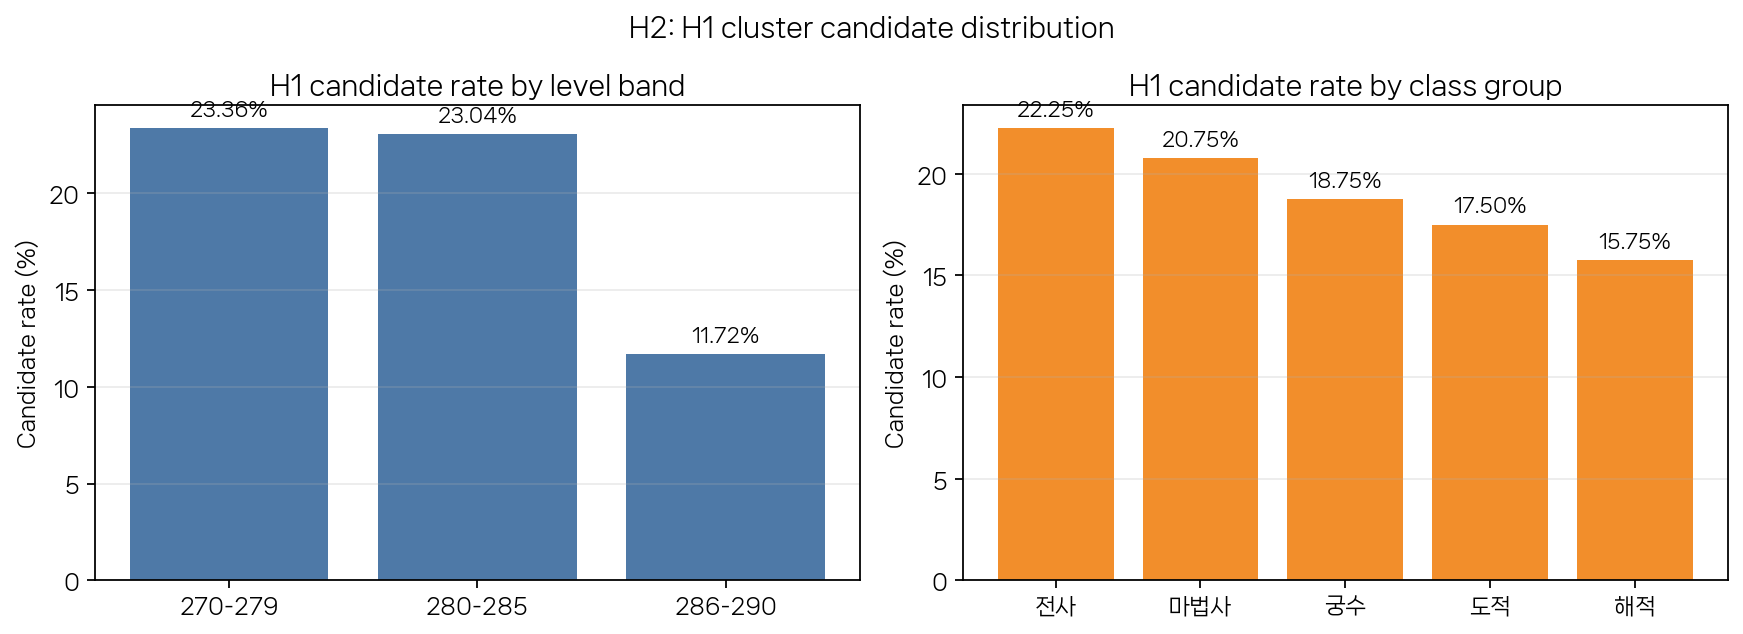

In [3]:
level_rows = pd.DataFrame(primary["tests"][0]["categories"])
level_rows["candidate_rate_pct"] = level_rows["candidate_rate"] * 100
display(level_rows[[
    "category", "n", "candidate_n", "candidate_expected", "candidate_rate_pct",
    "candidate_standardized_residual", "odds_ratio_vs_rest", "odds_ratio_ci95"
]].round(3))
display(Image(filename=str(h2_dir / "figures" / "candidate_distribution.png")))

## 레벨 통제 — 레벨 구간별 직업 계열 검정

직업 계열의 marginal 무유의가 레벨 구간 불균형에 가려진 결과인지 점검한다.
각 레벨 구간 안에서 직업 계열 × 후보를 분리 검정한다(소표본 구간은 Monte Carlo p 병행).


In [4]:
cwl = pd.DataFrame(primary["class_within_level"])
display(cwl[[
    "level_band", "n", "candidate_n", "chi2", "dof",
    "p_value", "monte_carlo_p_value", "min_expected_frequency", "cramers_v"
]].round(4))


,level_band,n,candidate_n,chi2,dof,p_value,monte_carlo_p_value,min_expected_frequency,cramers_v
0,270-279,107,25,2.6992,4,0.6094,0.6209,1.8692,0.1588
1,280-285,1176,271,5.6770,4,0.2246,0.2275,38.9447,0.0695
2,286-290,717,84,2.6921,4,0.6106,0.6114,7.4979,0.0613


## 해석

레벨 구간 분포는 `p < 0.05`이며 Holm 보정 후에도 유의하다. 표준화 잔차 기준 후보는 `280-285` 구간에 집중되고(잔차 +3.18, OR 1.96) `286-290` 구간에서 희박하다(잔차 -4.47, OR 0.44). 270-279는 비율은 높으나 표본이 작아(n=107) OR 신뢰구간이 1을 포함해 유의하지 않다. 따라서 H2는 **레벨 구간 측면에서 지지된다**.

직업 계열 분포는 Holm 보정 p=0.142로 유의하지 않고 Cramer's V=0.059로 효과크기도 무시 가능하다. 따라서 H2는 **직업 계열 측면에서는 지지되지 않는다**. 결론은 `레벨 구간 측면은 지지, 직업 계열 측면은 미지지`인 **부분 지지**로 정리한다.

**일반화 주의(표본 설계)**: 표본은 270-290 본캐 + ≥10/12 접속 통제 + 전투력 자연 하한 ~50M을 통과한 active/capable 캐릭터다(휴면·저레벨·저전투력 없음). 결론은 이 표본 설계 안에서만 일반화하며 전체 메이플 모집단으로 외삽하지 않는다. 레벨 구간 표본도 불균형(107/1176/717)이라 저레벨(270-279) 해석은 보수적으로 둔다. 모든 수치는 `RESULTS.md`와 동일하다.
